### Create Gaussian Process around dataset

In [19]:


%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')

from agent.components import RASK
from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, theoretical_param_bounds, ServiceVar
from agent.components.commons import SloSet

# s_type = ServiceType.QR
df_explore = pd.read_csv("../statics/agent_experience/metrics_ICSOC_EXPLORE.csv")
df_explore_preprocessed = RASK.preprocess_data(df_explore)

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


### Get the best epsilon (hyperparameter) for the solver

In [2]:
# from agent.components.commons import ServiceVar
# from agent.components.Optimizer import local_obj
# from agent.components.GaussianProcess import get_empirical_variable_bounds
# import numpy as np
#
# # Convert to a numpy array so we can do math on the whole vector
# x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))
#
# simple_param_bounds = get_empirical_variable_bounds(gp_service.training_data)[s_type]
# del simple_param_bounds[ServiceVar.PERFORMANCE]
# simple_param_bounds = list(simple_param_bounds.values())
#
# for e in [1e-5, 1e-3, 1e-2, 5e-2]:
#     # val_start uses the original center
#     val_start = local_obj(x_norm, s_type, slos_default, gp_service, simple_param_bounds)
#
#     # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
#     val_nudge = local_obj(x_norm + e, s_type, slos_default, gp_service, simple_param_bounds)
#
#     diff = abs(val_start - val_nudge)
#     print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

#### Create Gaussian Processes with certain shares of the exploration data set

In [10]:

gp_list = []
lml_history = []

data_splits = 100
tested_range = 20

for i in range(tested_range):
    gp_all_services = {}
    data_ratio = (i + 1) / data_splits
    lml_all_service = []

    for s in services:

        # Initialize and train GP model
        _gp = GASK(s, show_figures=False)
        _gp.init_model(df_explore, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        # print(f"Ratio {data_ratio}: LML = {lml:.2f}")
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished {i} / {tested_range} of the Gaussian Processes")

lml_history = np.array(lml_history)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 29 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offeri

Finished 0 / 20 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 205 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-pc-visualizer - Target: max_tp
INFO:multiscale:train_gp_models took 171 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: m

Finished 1 / 20 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 349 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a bett

...

Finished 17 / 20 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 775 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a bett

Finished 18 / 20 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 1152 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a bet

Finished 19 / 20 of the Gaussian Processes


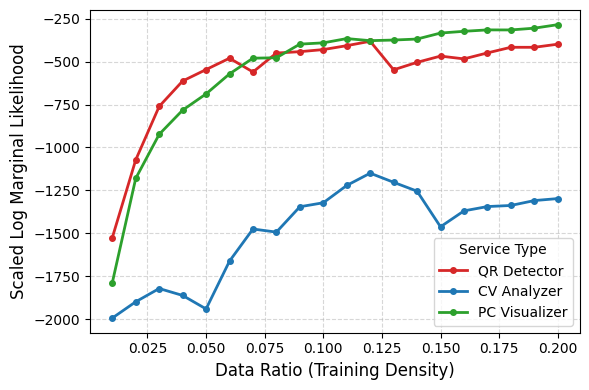

In [22]:

# 1. Define the X-axis (Data Ratios)
data_ratios = np.arange(1, tested_range + 1) / data_splits

# 2. Create the Figure
plt.figure(figsize=(6, 4))

# Service labels matching your 'services' list order
labels = ['QR Detector', 'CV Analyzer', 'PC Visualizer']
colors = ['#d62728', '#1f77b4', '#2ca02c'] # Red, Blue, Green

for i in range(lml_history.shape[1]):
    plt.plot(data_ratios, lml_history[:, i],
             marker='o', markersize=4, linewidth=2,
             label=labels[i], color=colors[i])

# 3. Formatting
# plt.title('Normalized GP Convergence (LML / samples)', fontsize=14)
plt.xlabel('Data Ratio (Training Density)', fontsize=12)
plt.ylabel('Scaled Log Marginal Likelihood', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Service Type")

# Optimization for the display
plt.tight_layout()
plt.savefig('../figures/E0/lml_convergence.pdf')

#### Find optimal parameter configs for each SLO x Service combination after seeing certain data shares

In [21]:
from agent.components.Optimizer import run_optimizer_multi

solution_history = []

for i in range(tested_range):
    for q in slos:
        for s in services:
            data_ratio = (i + 1) / tested_range
            gp = gp_list[i][s]

            # Run optimizer to find the best configuration
            solutions = run_optimizer_multi(s, q.value, gp, theoretical_param_bounds[s], runs=50)
            fitness, config = max(solutions, key=lambda x: x[0])

            # Predict performance (mu, sigma) for the chosen configuration
            x_state = {ServiceVar.COST: config[0], ServiceVar.QUALITY: config[1]}
            x_state = x_state | ({ServiceVar.MODEL: config[2]} if s == ServiceType.CV else {})
            mu, sigma = gp.predict(s, "max_tp", x_state)

            # Store everything needed for the next block
            # We include empirical_var_bounds here as it changes per iteration
            solution_history.append({
                'data_rate': data_ratio,
                'rep': None,
                'service_type': s.value,
                'slo_set': q.name,
                'p_fitness': fitness,
                # 'config': config,
                'dist': (mu, sigma),
                'cores': x_state[ServiceVar.COST],
                'data_quality': x_state[ServiceVar.QUALITY],
                'model_size': x_state[ServiceVar.MODEL] if s == ServiceType.CV else -1,
                # 'x_state': x_state,
            })

            print(f"Optimal fitness for {s.value} and {q.name} with {data_ratio * 10}% data: {fitness}")

Optimal fitness for elastic-workbench-qr-detector and DEFAULT with 0.5% data: 0.4061465977623307
Optimal fitness for elastic-workbench-cv-analyzer and DEFAULT with 0.5% data: 0.4580296523970574
Optimal fitness for elastic-workbench-pc-visualizer and DEFAULT with 0.5% data: 0.7387494472083642
Optimal fitness for elastic-workbench-qr-detector and HIGH_PERF with 0.5% data: 0.7820760264631599


KeyboardInterrupt: 

#### Export to candidate solution script, with each config repeated x times

In [5]:
repeatable_data = []
runs_per_config = 25

# Iterate through the list in steps of 3 (the size of your service triple)
for i in range(0, len(solution_history), 3):
    # Extract the current triple of rows
    triple = solution_history[i: i + 3]

    # Repeat this specific triple for the number of runs
    for run_idx in range(runs_per_config):
        for row in triple:
            new_row = row.copy()
            new_row['rep'] = run_idx + 1
            repeatable_data.append(new_row)

df_candidates = pd.DataFrame(repeatable_data)
df_candidates.to_csv(f'../statics/candidates/candidate_solutions_{tested_range}_{data_splits}_{runs_per_config}.csv',
                     index=False)